<font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br>



<font size="5" color='grey'> <b>
Agentic RAG – Deep Dive
</b></font> </br>

---

In [1]:
#@title 🔧 Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul

import os
os.environ["LANGSMITH_TRACING"]  = "true"
os.environ["LANGSMITH_PROJECT"]  = "M22-Agentic-RAG"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment, get_ipinfo, setup_api_keys,
    mprint, install_packages, mermaid, load_prompt,
    show_trace
)
setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.12
langchain-chroma                         1.1.0
langchain-classic                        1.0.3
langchain-community                      0.4.1
langchain-core                           1.2.19
langchain-ollama                         1.0.1
langchain-openai                         1.1.11
langchain-text-splitters                 1.1.1
langgraph                                1.1.2
langgraph-checkpoint                     4.0.1
langgraph-prebuilt                       1.0.8
langgraph-sdk                            0.3.11

IP-Adresse: 35.197.86.244
Hostname: 244.86.197.35.bc.googleusercontent.com
Stadt: The Dalles
Region: Oregon
Land: US
Koordinaten: 45.5946,-121.1787
Provider: AS396982 Google LLC
Postleitzahl: 97058
Zeitzone: America/Los_Angeles


In [2]:
#@title 🛠️ Installationen { display-mode: "form" }
install_packages([
    ('markitdown[all]', 'markitdown'),
    ('wikipedia', 'wikipedia'),
])

🔄 Installiere markitdown[all]...
✅ markitdown[all] erfolgreich installiert und importiert
🔄 Installiere wikipedia...
✅ wikipedia erfolgreich installiert und importiert


In [3]:
#@title 📂 Dokumente laden { display-mode: "form" }
#@title 📂 Dokumente { display-mode: "form" }
!rm -rf /content/files
!mkdir /content/files
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_1.txt  -o /content/files/biografien_1.txt
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_2.md   -o /content/files/biografien_2.md
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_3.pdf  -o /content/files/biografien_3.pdf
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_4.docx -o /content/files/biografien_4.docx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5324  100  5324    0     0  12476      0 --:--:-- --:--:-- --:--:-- 12468
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7868  100  7868    0     0  23920      0 --:--:-- --:--:-- --:--:-- 23987
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 68184  100 68184    0     0   113k      0 --:--:-- --:--:-- --:--:--  113k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 18743  100 18743    0     0  38814      0 --:--:-- --:--:-- --:--:-- 38885


# 1 | Übersicht
---

<p><font color='black' size='5'>Von Pipeline zu Agentic RAG</font></p>

In ***RAG-Chain mit LangChain***/*RAG-Agent* haben Sie RAG als **statische Pipeline** kennengelernt:

```
Query → Retrieve → [Grade] → [Rewrite] → Generate
```

Der Workflow ist zwar adaptiv (CRAG), aber die **Struktur ist fest**:
Jede Query durchläuft dieselben Schritte.

**Agentic RAG** geht einen Schritt weiter:

| Frage | Pipeline RAG | Agentic RAG |
|-------|-------------|-------------|
| **Wann retrieven?** | Immer | Agent entscheidet |
| **Was retrieven?** | Eine Query | Beliebig viele, sequenziell |
| **Wie retrieven?** | Feste Strategie | Agent wählt Strategie |
| **Wie oft retrieven?** | Einmal (oder mit Retry) | So oft wie nötig |
| **Flexibilität** | Mittel | Hoch |
| **Komplexität** | Mittel | Hoch |


In [4]:
#@markdown   <p><font size="4" color='green'>  Pipeline vs Agentic RAG</font> </br></p>

diagram = '''
flowchart LR
    subgraph PIPELINE["Pipeline RAG (M10/M11)"]
        P1[Query] --> P2[Retrieve]
        P2 --> P3[Grade]
        P3 --> P4[Generate]
    end

    subgraph AGENTIC["Agentic RAG (M23)"]
        A1[Query] --> A2{Agent}
        A2 -->|retrieve_broad| A3[Docs 1]
        A2 -->|retrieve_specific| A4[Docs 2]
        A2 -->|retrieve_person| A5[Docs 3]
        A3 & A4 & A5 --> A2
        A2 -->|generate| A6[Antwort]
    end

    style PIPELINE fill:#E3F2FD,stroke:#1976D2
    style AGENTIC  fill:#E8F5E9,stroke:#388E3C
    style A2 fill:#FF9800,color:#fff
'''
mermaid(diagram, width=900)

# 2 | Setup: Vektordatenbank & Retrieval-Tools
---

<p><font color='black' size='5'>Imports & Modell</font></p>

In [5]:
from typing import Annotated, List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent
from IPython.display import Image as IPImage, display

# ── Konfigurationskonstanten ───────────────────────────────────────────────
MAX_RETRIES = 2   # API-Retry-Versuche bei transienten Fehlern (with_retry)

llm           = init_chat_model('openai:gpt-4o-mini', temperature=0.0)  # Worker-Agenten
planner_llm   = init_chat_model('openai:o3')          # Routing/Klassifizierung (kein temperature, siehe Modell_Auswahl_Guide)
generator_llm = init_chat_model('openai:gpt-5.1')     # Antwortsynthese (kein temperature, siehe Modell_Auswahl_Guide)
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
print('✅ LLM und Embeddings initialisiert')
print(f'   MAX_RETRIES = {MAX_RETRIES}')

✅ LLM und Embeddings initialisiert
   MAX_RETRIES = 2


<p><font color='black' size='5'>Vektordatenbank aufbauen</font></p>

In [6]:
from markitdown import MarkItDown

md_converter = MarkItDown()
documents = []

for fname in os.listdir('./files'):
    fpath = f'./files/{fname}'
    try:
        result = md_converter.convert(fpath)
        documents.append(Document(
            page_content=result.text_content,
            metadata={'source': fname}
        ))
        print(f'✅ {fname}')
    except Exception as e:
        print(f'⚠️ {fname}: {e}')

splitter   = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
split_docs = splitter.split_documents(documents)

vectorstore = Chroma.from_documents(
    documents=split_docs,
    embedding=embeddings,
    collection_name='agentic_rag_biografien'
)
print(f'\n📦 {len(split_docs)} Chunks in Vektordatenbank')

✅ biografien_2.md
✅ biografien_3.pdf
✅ biografien_4.docx
✅ biografien_1.txt

📦 69 Chunks in Vektordatenbank


# 3 | RAG als Tool
---

<p><font color='black' size='5'>Konzept</font></p>

Im einfachsten Agentic RAG-Muster wird der Retriever als **Tool** verpackt.
Der Agent entscheidet selbst:

- **Ob** er retrievet (ggf. antwortet er aus eigenem Wissen)
- **Wie** er die Query formuliert
- **Ob** er mehrfach retrievet (mit unterschiedlichen Queries)

```python
@tool
def retrieve(query: str) -> str:
    """Sucht relevante Dokumente in der Wissensbasis."""
    docs = retriever.invoke(query)
    return '\n\n'.join([d.page_content for d in docs])
```

Der Agent nutzt das Tool im ReAct-Loop:
**Think** → brauche ich Dokumente? → **Act** → retrieve() → **Observe** → genug Info?

In [7]:
#@markdown   <p><font size="4" color='green'>  RAG Tool im ReAct-Loop</font> </br></p>

diagram = '''
flowchart TD
    Q[/Query/] --> AGENT{ReAct Agent}
    AGENT -->|Think: Brauche Infos| RT[retrieve Tool]
    RT -->|Dokumente| AGENT
    AGENT -->|Think: Genug Infos| GEN[Antwort generieren]
    GEN --> ANT[/Antwort/]

    AGENT -->|Think: Kein Retrieval nötig| GEN2[Direkt antworten]
    GEN2 --> ANT

    style AGENT fill:#FF9800,color:#fff
    style RT    fill:#2196F3,color:#fff
    style GEN   fill:#4CAF50,color:#fff
    style GEN2  fill:#4CAF50,color:#fff
'''
mermaid(diagram, width=700)

<p><font color='black' size='5'>RAG Tool definieren</font></p>

In [8]:
retriever = vectorstore.as_retriever(search_kwargs={'k': 4})

@tool
def retrieve(query: str) -> str:
    """Sucht relevante Informationen in der Wissensbasis (Biografien).
    Nutze dieses Tool wenn du Fakten ueber Personen benoenigst.
    """
    docs = retriever.invoke(query)
    if not docs:
        return 'Keine relevanten Dokumente gefunden.'
    results = []
    for i, doc in enumerate(docs, 1):
        results.append(f'[Quelle {i}: {doc.metadata.get("source","?")}]\n{doc.page_content}')
    return '\n\n'.join(results)

print('✅ RAG Tool definiert')

✅ RAG Tool definiert


<p><font color='black' size='5'>Agent erstellen & testen</font></p>

In [9]:
# ── Think Tool (Strategische Reflexion) ───────────────────────────────────
# Aus LangGraph Production-Patterns: Der Agent reflektiert nach jedem
# Retrieval-Schritt bevor er weitere Tool-Calls macht.
# Verhindert unnötige Folge-Retrievals und verbessert die Antwortqualität.

@tool
def think(reflection: str) -> str:
    """Strategisches Nachdenken nach einem Retrieval-Schritt.

    Nutze dieses Tool nach jedem retrieve-Aufruf:
    - Sind die gefundenen Dokumente relevant fuer die Frage?
    - Habe ich genug Informationen fuer eine vollstaendige Antwort?
    - Falls nicht: welche spezifischere Query wuerde helfen?

    Args:
        reflection: Analyse der gefundenen Dokumente und geplanter naechster Schritt
    """
    return f"Reflexion notiert: {reflection}"

print('✅ think Tool definiert (strategische Reflexion nach Retrieval-Schritten)')

✅ think Tool definiert (strategische Reflexion nach Retrieval-Schritten)


In [10]:
rag_agent = create_react_agent(
    llm,
    tools=[retrieve, think],
    prompt=SystemMessage(
        'Du bist ein hilfreicher Kursassistent mit Zugriff auf eine Biografien-Datenbank.\n\n'
        '<Task>\n'
        'Beantworte Fragen zu Personen aus der Datenbank praezise und mit Quellenbelegen.\n'
        '</Task>\n\n'
        '<Instructions>\n'
        '1. Rufe IMMER zuerst retrieve auf, bevor du antwortest\n'
        '2. Nutze think nach dem Retrieval: Sind die Dokumente relevant? Genug Infos?\n'
        '3. Auch bei Unsicherheit: erst retrieven, dann beurteilen\n'
        '4. Belege jede Aussage mit den gefundenen Quellen\n'
        '5. Antworte auf Deutsch\n'
        '</Instructions>\n\n'
        '<Hard Limits>\n'
        'Tool-Budget: maximal 2 retrieve-Aufrufe pro Anfrage.\n'
        'Sofort antworten wenn: Du genuegend Kontext fuer eine vollstaendige Antwort hast.\n'
        '</Hard Limits>'
    )
)

print('✅ RAG Agent erstellt')
print('   tools: [retrieve, think]')

✅ RAG Agent erstellt
   tools: [retrieve, think]


In [11]:
# Test 1: Frage die Retrieval benötigt
result = rag_agent.invoke(
    {'messages': [HumanMessage('Wer sind die Personen in der Datenbank?')]},
    config={'run_name': 'M22-Kap3-RAG-Test', 'tags': ['m22', 'rag-agent']},
)
mprint('## 🎯 Test: RAG Agent')
mprint(result['messages'][-1].content)

## 🎯 Test: RAG Agent

In der Biografien-Datenbank sind folgende Personen verzeichnet:

1. **Kazuki Tanaka**: Er ist Gedächtnisarchäologe und KI-Ethiker. Tanaka entwickelt Technologien, um verlorene oder beschädigte persönliche Erinnerungen zu rekonstruieren. Er hat ein System namens "MemoryBridge" entwickelt, das fragmentarische Erinnerungen älterer Menschen mit Demenz mit familiären Archiven und digitalen Spuren verbindet. Seine Arbeit wirft grundlegende Fragen zur Identität und Authentizität auf und er hat einen ethischen Rahmen für das Feld der "Erinnerungsaugmentation" geschaffen.

2. **Oliver Jensen**: Jensen ist Archäoinformatiker und digitaler Anthropologe. Er erstellt virtuelle Rekonstruktionen längst verschwundener Kulturen und hat die Plattform "CivSim" entwickelt, die archäologische Daten, genetische Analysen und KI kombiniert, um das Leben prähistorischer Gemeinschaften zu simulieren. Sein Projekt ermöglicht es, mit den ersten Bauern Europas zu interagieren und deren Entscheidungsprozesse nachzuvollziehen.

3. **Elena Vorobyova**: Sie ist Kryonikbiologin und Umwelttechnologin, die Methoden zur Konservierung vom Aussterben bedrohter Pflanzenarten in ewigem Eis entwickelt hat. Ihr "Arktischer Genbank"-Komplex in Spitzbergen beherbergt über 5.000 gefährdete Arten. Vorobyova hat erfolgreich Pflanzen wiederhergestellt, die in ihren natürlichen Habitaten bereits ausgestorben waren, und ihre Forschung hat auch Anwendungen in der Weltraumkolonisation gefunden.

Diese Personen sind in ihren jeweiligen Fachgebieten innovativ tätig und tragen zur Forschung und Entwicklung in wichtigen wissenschaftlichen Bereichen bei.

# 4 | Multi-Hop RAG
---

<p><font color='black' size='5'>Konzept</font></p>

**Multi-Hop RAG** löst komplexe Fragen, die **mehrere Retrieval-Schritte** erfordern:

```
Frage: 'Vergleiche Person A und Person B'
  Hop 1: retrieve('Person A')  → Fakten A
  Hop 2: retrieve('Person B')  → Fakten B
  Generate: Vergleich aus beiden Fakten
```

**Warum wichtig?**
- Einfache RAG-Pipelines retrieven nur einmal
- Für Vergleiche, Zusammenhänge, mehrteilige Fragen reicht das nicht
- Ein Agent kann **iterativ** retrieven und Zwischenergebnisse nutzen

In [12]:
#@markdown   <p><font size="4" color='green'>  Multi-Hop Retrieval</font> </br></p>

diagram = '''
flowchart TD
    Q[/Komplexe Frage:\nVergleiche A und B/] --> AG{Agent}

    AG -->|Hop 1: retrieve Person A| D1[Docs: Person A]
    D1 --> AG
    AG -->|Hop 2: retrieve Person B| D2[Docs: Person B]
    D2 --> AG
    AG -->|Alle Infos vorhanden| GEN[Vergleich generieren]
    GEN --> ANT[/Antwort mit\nbeiden Perspektiven/]

    style AG  fill:#FF9800,color:#fff
    style D1  fill:#2196F3,color:#fff
    style D2  fill:#9C27B0,color:#fff
    style GEN fill:#4CAF50,color:#fff
'''
mermaid(diagram, width=700)

<p><font color='black' size='5'>Spezialisierte Retrieval-Tools</font></p>

Für Multi-Hop-RAG lohnt es sich, **mehrere spezialisierte Tools** anzubieten
statt eines generischen `retrieve`-Tools:

In [13]:
retriever_broad    = vectorstore.as_retriever(search_kwargs={'k': 6})
retriever_specific = vectorstore.as_retriever(search_kwargs={'k': 2})

@tool
def retrieve_person(name: str) -> str:
    """Sucht Informationen ueber eine bestimmte Person in der Datenbank.
    Nutze dies wenn du Fakten zu einer spezifischen Person brauchst.
    """
    docs = retriever_specific.invoke(f'Person {name} Biografie')
    if not docs:
        return f'Keine Informationen zu {name} gefunden.'
    return '\n\n'.join([d.page_content for d in docs])

@tool
def retrieve_thema(thema: str) -> str:
    """Sucht Informationen zu einem Thema oder Sachverhalt in der Datenbank.
    Nutze dies fuer thematische Fragen (Berufe, Leistungen, Zeiträume).
    """
    docs = retriever_broad.invoke(thema)
    if not docs:
        return f'Keine Informationen zu Thema "{thema}" gefunden.'
    return '\n\n'.join([d.page_content[:400] for d in docs])

print('✅ Spezialisierte Retrieval-Tools definiert')

✅ Spezialisierte Retrieval-Tools definiert


<p><font color='black' size='5'>Multi-Hop Agent</font></p>

In [14]:
MULTI_HOP_PROMPT = load_prompt(
    "https://github.com/ralf-42/Agenten/blob/main/05_prompt/m22_multi_hop_agent_prompt.md",
    mode="S",
)
multi_hop_agent = create_react_agent(
    llm,
    tools=[retrieve_person, retrieve_thema, think],
    prompt=MULTI_HOP_PROMPT,
)
print('✅ Multi-Hop Agent erstellt')
print('   tools: [retrieve_person, retrieve_thema, think]')

✅ Multi-Hop Agent erstellt
   tools: [retrieve_person, retrieve_thema, think]


In [15]:
# Test: Konkrete Personen → Agent muss retrieve_person für jede Person separat aufrufen
frage = 'Vergleiche Leandro Vasquez und Thoren Navarro: Was haben sie gemeinsam und wo unterscheiden sie sich?'

result_mh = multi_hop_agent.invoke(
    {'messages': [HumanMessage(frage)]},
    config={
        'run_name': 'M22-Kap4-MultiHop-Test',
        'tags':     ['m22', 'multi-hop'],
        'recursion_limit': 20,
    },
)

mprint('## 🎯 Multi-Hop Ergebnis')
mprint(f'**Frage:** {frage}\n')

# Individuelle Tool-Aufrufe zählen (nicht Nachrichten)
tool_calls = sum(
    len(m.tool_calls)
    for m in result_mh['messages']
    if hasattr(m, 'tool_calls') and m.tool_calls
)
mprint(f'**Retrieval-Hops:** {tool_calls}\n')
mprint(result_mh['messages'][-1].content)

## 🎯 Multi-Hop Ergebnis

**Frage:** Vergleiche Leandro Vasquez und Thoren Navarro: Was haben sie gemeinsam und wo unterscheiden sie sich?


**Retrieval-Hops:** 3


Leandro Vasquez und Thoren Navarro haben einige Gemeinsamkeiten, aber auch deutliche Unterschiede:

### Gemeinsamkeiten:
1. **Fachgebiet**: Beide sind Archäologen, die sich mit der Erhaltung und Rekonstruktion von Kulturgütern beschäftigen. Vasquez arbeitet mit historischen Simulationen, während Navarro sich auf Unterwasserarchäologie konzentriert.
2. **Technologieeinsatz**: Beide nutzen moderne Technologien in ihrer Arbeit. Vasquez verwendet VR-Technologie zur Rekonstruktion historischer Epochen, während Navarro spezialisierte Tauchroboter entwickelt, um versunkene Städte zu kartieren.
3. **Interdisziplinarität**: Beide kombinieren ihr archäologisches Wissen mit anderen Disziplinen – Vasquez mit digitaler Archäologie und Navarro mit Meeresbiologie und Robotik.

### Unterschiede:
1. **Fokus**: Vasquez konzentriert sich auf die Rekonstruktion vergangener Epochen (z.B. antikes Rom, mittelalterliches Japan), während Navarro sich mit der Erhaltung von Kulturgütern, die durch den Klimawandel bedroht sind, beschäftigt.
2. **Methoden**: Vasquez arbeitet hauptsächlich mit virtuellen Simulationen und berät Drehbuchautoren, während Navarro Audiosensoren und Tauchroboter einsetzt, um akustische Daten von Ökosystemen zu sammeln und zu analysieren.
3. **Umweltfokus**: Navarro hat einen starken Fokus auf den Umweltschutz und die Auswirkungen des Klimawandels auf Kulturgüter, während Vasquez sich mehr auf die historische Genauigkeit und die immersive Erfahrung konzentriert.

Zusammenfassend lässt sich sagen, dass beide Fachleute innovative Ansätze in der Archäologie verfolgen, jedoch unterschiedliche Schwerpunkte und Methoden haben.

# 5 | Adaptive Retrieval mit LangGraph
---

<p><font color='black' size='5'>Konzept</font></p>

Bei **Adaptive Retrieval** entscheidet der Agent zu Beginn, welche Retrieval-Strategie
am besten zur Frage passt:

| Query-Typ | Strategie | Beispiel |
|-----------|-----------|----------|
| **Faktenfrage** | Direct Retrieve (k=2) | 'Wann wurde X geboren?' |
| **Vergleichsfrage** | Multi-Hop (k=3 pro Person) | 'Vergleiche X und Y' |
| **Themafrage** | Broad Retrieve (k=6) | 'Was sind typische Eigenschaften?' |
| **Kein Retrieval** | Direct Answer | 'Was ist 2+2?' |

Wir bauen dies als **LangGraph-StateGraph** mit Routing:

In [16]:
#@markdown   <p><font size="4" color='green'>  Adaptive Retrieval Routing</font> </br></p>

diagram = '''
flowchart TD
    Q[/Query/] --> CLASS[Query Classifier]

    CLASS -->|fakt| DIRECT[Direct Retrieve\nk=2]
    CLASS -->|vergleich| MULTI[Multi-Hop\nretrieve x2]
    CLASS -->|thema| BROAD[Broad Retrieve\nk=6]
    CLASS -->|kein_retrieval| GEN_DIRECT[Direkt generieren]

    DIRECT & MULTI & BROAD --> GEN[Generate]
    GEN_DIRECT --> ANT[/Antwort/]
    GEN --> ANT

    style CLASS       fill:#607D8B,color:#fff
    style DIRECT      fill:#2196F3,color:#fff
    style MULTI       fill:#9C27B0,color:#fff
    style BROAD       fill:#FF5722,color:#fff
    style GEN_DIRECT  fill:#4CAF50,color:#fff
    style GEN         fill:#4CAF50,color:#fff
'''
mermaid(diagram, width=750)

<p><font color='black' size='5'>State & Classifier</font></p>

In [17]:
class AdaptiveRAGState(TypedDict):
    query:        str
    query_type:   str              # 'fakt' | 'vergleich' | 'thema' | 'kein_retrieval'
    documents:    List[Document]
    answer:       str

class QueryKlassifizierung(BaseModel):
    query_type: str = Field(
        description="'fakt' fuer Faktenfragen, 'vergleich' fuer Vergleiche, "
                    "'thema' fuer Themafragen, 'kein_retrieval' wenn kein Retrieval noetig"
    )
    begruendung: str = Field(description='Kurze Begruendung fuer die Klassifizierung')

# .with_retry(): schützt vor transienten API-Fehlern beim Classifier-Aufruf
classifier_llm = (
    planner_llm
    .with_structured_output(QueryKlassifizierung)
    .with_retry(stop_after_attempt=MAX_RETRIES)
)

print('✅ State und Classifier konfiguriert')
print(f'   classifier_llm: o3 + with_structured_output + with_retry(stop_after_attempt={MAX_RETRIES})')

✅ State und Classifier konfiguriert
   classifier_llm: o3 + with_structured_output + with_retry(stop_after_attempt=2)


<p><font color='black' size='5'>Graph Nodes</font></p>

In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def classify_node(state: AdaptiveRAGState) -> dict:
    result = classifier_llm.invoke([
        SystemMessage('Klassifiziere die folgende Query fuer ein RAG-System.\n'
                      'Typen: fakt (eine Person/Fakt), vergleich (mehrere Personen),\n'
                      'thema (uebergreifendes Thema), kein_retrieval (allg. Wissen)'),
        HumanMessage(state['query'])
    ])
    print(f'🔀 Query-Typ: {result.query_type} – {result.begruendung}')
    return {'query_type': result.query_type}

def direct_retrieve_node(state: AdaptiveRAGState) -> dict:
    docs = vectorstore.as_retriever(search_kwargs={'k': 2}).invoke(state['query'])
    print(f'🔍 Direct Retrieve: {len(docs)} Docs')
    return {'documents': docs}

def multi_hop_node(state: AdaptiveRAGState) -> dict:
    # Zwei separate Retrievals, merged
    r = vectorstore.as_retriever(search_kwargs={'k': 3})
    docs1 = r.invoke(state['query'] + ' erste Person')
    docs2 = r.invoke(state['query'] + ' zweite Person')
    docs  = docs1 + docs2
    print(f'🔍 Multi-Hop Retrieve: {len(docs)} Docs (2 Hops)')
    return {'documents': docs}

def broad_retrieve_node(state: AdaptiveRAGState) -> dict:
    docs = vectorstore.as_retriever(search_kwargs={'k': 6}).invoke(state['query'])
    print(f'🔍 Broad Retrieve: {len(docs)} Docs')
    return {'documents': docs}

def generate_node(state: AdaptiveRAGState) -> dict:
    docs    = state.get('documents', [])
    context = '\n\n'.join([d.page_content for d in docs]) if docs else 'Kein Kontext verfuegbar.'
    prompt  = ChatPromptTemplate.from_messages([
        ('system', 'Beantworte die Frage basierend auf dem Kontext. Antworte auf Deutsch.'),
        ('human',  'Kontext:\n{context}\n\nFrage: {query}')
    ])
    chain  = prompt | generator_llm | StrOutputParser()
    answer = chain.invoke({'context': context, 'query': state['query']})
    return {'answer': answer}

def router(state: AdaptiveRAGState) -> str:
    return state['query_type']

print('✅ Nodes definiert')

✅ Nodes definiert


<p><font color='black' size='5'>Graph kompilieren</font></p>

In [19]:
builder = StateGraph(AdaptiveRAGState)

builder.add_node('classify',       classify_node)
builder.add_node('direct_retrieve', direct_retrieve_node)
builder.add_node('multi_hop',      multi_hop_node)
builder.add_node('broad_retrieve', broad_retrieve_node)
builder.add_node('generate',       generate_node)

builder.add_edge(START, 'classify')
builder.add_conditional_edges(
    'classify',
    router,
    {
        'fakt':           'direct_retrieve',
        'vergleich':      'multi_hop',
        'thema':          'broad_retrieve',
        'kein_retrieval': 'generate',
    }
)
builder.add_edge('direct_retrieve', 'generate')
builder.add_edge('multi_hop',       'generate')
builder.add_edge('broad_retrieve',  'generate')
builder.add_edge('generate',        END)

adaptive_app = builder.compile()
print('✅ Adaptive RAG Graph kompiliert')

✅ Adaptive RAG Graph kompiliert


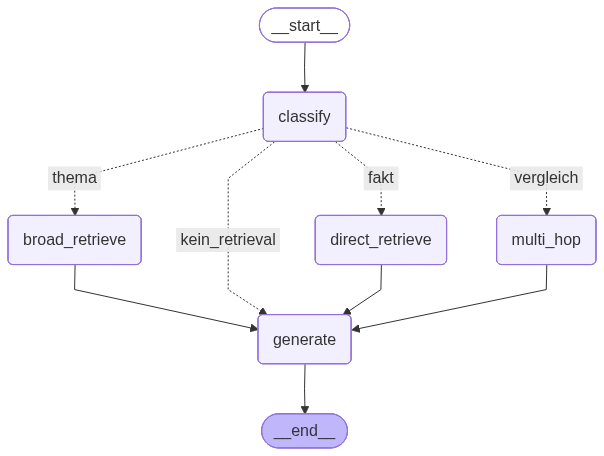

In [20]:
# --- VIZ ---
display(IPImage(adaptive_app.get_graph().draw_mermaid_png()))

<p><font color='black' size='5'>Tests: verschiedene Query-Typen</font></p>

In [21]:
test_queries = [
    'Was ist 42 geteilt durch 6?',
    'Welche Berufe oder Talente haben die Personen in der Datenbank?',
    'Vergleiche die Personen in der Datenbank miteinander.',
]

for q in test_queries:
    res = adaptive_app.invoke({'query': q, 'documents': [], 'answer': '', 'query_type': ''})
    mprint(f'---\n**Query:** {q}')
    mprint(f'**Typ:** `{res["query_type"]}`')
    mprint(f'**Antwort:** {res["answer"][:300]}...')

🔀 Query-Typ: kein_retrieval – Einfache Rechenaufgabe, erfordert kein Retrieval von Informationsquellen


---
**Query:** Was ist 42 geteilt durch 6?

**Typ:** `kein_retrieval`

**Antwort:** 42 geteilt durch 6 ist 7....

🔀 Query-Typ: thema – Frage zielt auf eine allgemeine Übersicht (Thema) der in der Datenbank vorhandenen Berufe/Talente, nicht auf einzelne Fakten zu einer Person oder Vergleich zwischen Personen.
🔍 Broad Retrieve: 6 Docs


...

**Antwort:** Aus dem gegebenen Kontext lassen sich folgende Berufe/Talente erkennen:

1. **Person 1**  
   - Inspiriert Menschen für **Astronomie** (vermutlich Astronomie-Vermittlerin / Wissenschaftskommunikatorin)  
   - Tochter einer **Planetengeologin** und eines **Game-Designers**  
   - Leitet ein **Bürgerw...

🔀 Query-Typ: vergleich – Die Anfrage fordert einen Vergleich mehrerer Personen in der Datenbank.
🔍 Multi-Hop Retrieve: 6 Docs (2 Hops)


---
**Query:** Vergleiche die Personen in der Datenbank miteinander.

**Typ:** `vergleich`

**Antwort:** Beide Personen arbeiten mit „Rekonstruktion“, aber auf sehr unterschiedlichen Ebenen:

1. **Fachgebiet und Objekt der Rekonstruktion**  
   - **Oliver Jensen**  
     - Archäoinformatiker, digitaler Anthropologe  
     - Rekonstruiert **verlorene Kulturen** (prähistorische Gesellschaften, Alltag, Sp...

# 6 | Vergleich: Pipeline vs Agentic RAG
---

| Kriterium | Advanced RAG  | Agentic RAG  |
|-----------|------------------------------|-------------------|
| **Architektur** | Fester Workflow | Agent entscheidet |
| **Retrieval-Anzahl** | 1 (ggf. Retry) | Beliebig (Multi-Hop) |
| **Query-Verarbeitung** | Direkt / Rewrite | Agent formuliert selbst |
| **Flexibilität** | Mittel | Hoch |
| **Latenz** | Niedrig–Mittel | Mittel–Hoch |
| **Kosten** | Vorhersagbar | Variabel |
| **Debugging** | Einfach | Aufwendiger |
| **Geeignet fuer** | Klare, ähnliche Queries | Komplexe, diverse Queries |

**Wann welchen Ansatz wählen?**

```
Queries sind ähnlich und vorhersagbar?
  → JA: Advanced RAG Pipeline (schneller, günstiger, einfacher)
  → NEIN: Queries sind komplex / divers?
      → JA: Agentic RAG
      → NEIN: Brauche ich Multi-Hop?
          → JA: Agentic RAG mit Multi-Hop
          → NEIN: Self-RAG oder CRAG (→ *Advanced RAG – Pipeline-Patterns*)
```

In [22]:
#@markdown   <p><font size="4" color='green'>  LangSmith Trace-Analyse</font> </br></p>

import time as _t; _t.sleep(2)
show_trace("M22-Agentic-RAG", limit=3, show_steps=True)

## LangSmith Trace — `M22-Agentic-RAG`

| Run | Status | Dauer | Child-Runs |
|-----|--------|-------|------------|
| `LangGraph` | ✅ success | 12.8s | 0 |
| `LangGraph` | ✅ success | 10.2s | 0 |
| `LangGraph` | ✅ success | 2.6s | 0 |


### Steps — letzter Run: `LangGraph`

| # | Typ | Name | Status | Dauer |
|---|-----|------|--------|-------|
| 1 | `chain` | `generate` | ✅ | 9.9s |
| 2 | `chain` | `multi_hop` | ✅ | 0.4s |
| 3 | `chain` | `classify` | ✅ | 2.5s |

# A | Aufgaben
---

<p><font color='darkblue' size="4">
📌 <b>Wichtig</b>
</font></p>

Die Aufgabestellungen unten bieten Anregungen, Sie können aber auch gerne eine andere Herausforderung angehen.

**Hinweis zur Lösungshilfe:**
> In diesem Kurs dürfen und sollen Sie generative KI auch als Unterstützung beim Lernen und Entwickeln nutzen. Wenn Sie bei einer Aufgabe festhängen, können Sie zum Beispiel Gemini in Google Colab verwenden, um Fehlermeldungen besser zu verstehen, Ideen für Teilschritte zu bekommen oder Code-Varianten zu prüfen.
> <br>**Wichtig ist nur:** Die KI dient als Lern- und Entwicklungshilfe. Der Schwerpunkt des Kurses bleibt darauf, KI-Agenten selbst zu verstehen, aufzubauen und gezielt weiterzuentwickeln.

<p><font color='black' size='5'>Aufgabe 1: Tool-Aufruf-Protokoll</font></p>

Erweitere den Multi-Hop Agent um ein **Protokoll aller Tool-Aufrufe**:

1. Extrahiere aus `result['messages']` alle `ToolMessage`-Einträge
2. Zeige für jeden Aufruf: Tool-Name, Query, Anzahl gefundener Zeichen
3. Berechne die Gesamtanzahl der Retrieval-Hops

**Tipp:** `from langchain_core.messages import ToolMessage`

<p><font color='black' size='5'>Aufgabe 2: Hallucination Guard</font></p>

Füge dem Adaptive RAG Graph einen **Hallucination Check Node** hinzu
(aufbauend auf Aufgabe 1 aus diesem Modul):

1. Node nach `generate`: prüft ob Antwort durch Docs gestützt ist
2. Pydantic-Modell: `{is_grounded: bool, confidence: float, problematic_claims: list}`
3. Wenn `is_grounded=False`: generiere Antwort neu mit strengerem Prompt
4. Maximal 2 Regenerierungs-Versuche

<p><font color='black' size='5'>Aufgabe 3: RAG + Supervisor</font></p>

Kombiniere **Agentic RAG** mit dem **Supervisor Pattern**:

1. Supervisor koordiniert: `recherche_agent` (Multi-Hop RAG) + `schreib_agent`
2. Recherche-Agent nutzt `retrieve_person` und `retrieve_thema` als Tools
3. Schreib-Agent erstellt aus den gefundenen Fakten einen strukturierten Bericht

**Bonus:** Füge LangSmith-Tracing mit `run_name` und `tags` hinzu
und analysiere die Kosten des Multi-Hop-Retrievals.